$\Huge \rm Causality$

Francisco Förster Burón — MDS7201, Data Science Project Course

A 45-minute introduction to causal reasoning for data scientists.

---

**What you should take away from today:**

1. *Correlation is not causation* — and there is a precise reason why.
2. *Directed acyclic graphs (DAGs)* are a simple language to talk about causal structure.
3. *Three structures* (confounders, mediators, colliders) determine what you should and should not adjust for.
4. Given a DAG, *backdoor adjustment* gives you an unbiased estimate of a causal effect from observational data.

# 1. Motivation: Simpson's paradox

Before we talk about causality formally, let's look at a phenomenon that is both famous and unsettling. The same dataset can tell two opposite stories depending on whether we look at it aggregated or split into groups.

![Simpson's paradox animation](Simpsons_paradox_-_animation.gif)

In the animation above, every subgroup shows a *positive* trend, but when we pool all the points together, the overall trend is *negative*. Neither view is wrong — they answer different questions.

## Berkeley graduate admissions, 1973

The most cited real example. UC Berkeley was sued for gender discrimination in graduate admissions because, at the aggregate level, men were admitted at a much higher rate than women. But when the data were broken down by department, the picture changed.

Let's load the (rounded) data for the six largest departments and see for ourselves.

In [11]:
import pandas as pd

berkeley = pd.DataFrame({
    'Department':    ['A', 'B', 'C', 'D', 'E', 'F'],
    'Men_Applied':   [825, 560, 325, 417, 191, 373],
    'Men_Admitted':  [511, 353, 120, 138,  53,  22],
    'Women_Applied':  [108, 25, 593, 375, 393, 341],
    'Women_Admitted': [ 89, 17, 202, 131,  94,  24],
})

berkeley['Men_Rate']   = berkeley['Men_Admitted']   / berkeley['Men_Applied']
berkeley['Women_Rate'] = berkeley['Women_Admitted'] / berkeley['Women_Applied']

# Aggregate (pooled across departments)
agg_men   = berkeley['Men_Admitted'].sum()   / berkeley['Men_Applied'].sum()
agg_women = berkeley['Women_Admitted'].sum() / berkeley['Women_Applied'].sum()

print(f'Aggregate admission rate — men:   {agg_men:.1%}')
print(f'Aggregate admission rate — women: {agg_women:.1%}')
print()
print(berkeley[['Department', 'Men_Applied', 'Women_Applied', 'Men_Rate', 'Women_Rate']].to_string(index=False))

Aggregate admission rate — men:   44.5%
Aggregate admission rate — women: 30.4%

Department  Men_Applied  Women_Applied  Men_Rate  Women_Rate
         A          825            108  0.619394    0.824074
         B          560             25  0.630357    0.680000
         C          325            593  0.369231    0.340641
         D          417            375  0.330935    0.349333
         E          191            393  0.277487    0.239186
         F          373            341  0.058981    0.070381


Two facts:

- **Aggregated:** men are admitted at a noticeably higher rate than women.
- **Per department:** women are admitted at a similar or even *higher* rate than men in most departments.

What is going on? Look at where the applications go. Women applied disproportionately to competitive departments (low admission rates for everyone), men to less competitive ones. The aggregate gap is not driven by within-department discrimination; it is driven by *which departments people applied to*.

Which number is the "true" one depends on the question. *"Is Berkeley discriminating at the point of admission?"* and *"Is the system as a whole favouring men?"* are different questions, and they need different analyses. **Statistics alone cannot tell you which to use — you need a model of the underlying causal story.** That is what the rest of this class is about.

# 2. Correlation vs. causation: the confounder

Simpson's paradox is one face of a deeper problem: a correlation between two variables can be entirely produced by a *third* variable that influences both. We call that third variable a **confounder**.

Let's see this with a synthetic example where we know the ground truth, because we generated it ourselves.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')
np.random.seed(42)

n = 200

# Hidden cause: temperature
temperature = np.random.normal(loc=25, scale=5, size=n)

# Both ice cream sales and shark attacks are driven by temperature.
# Neither one causes the other.
ice_cream_sales = temperature * 10 + np.random.normal(0, 5, size=n)
shark_attacks   = temperature *  2 + np.random.normal(0, 2, size=n)

df = pd.DataFrame({
    'Temperature':   temperature,
    'IceCreamSales': ice_cream_sales,
    'SharkAttacks':  shark_attacks,
})

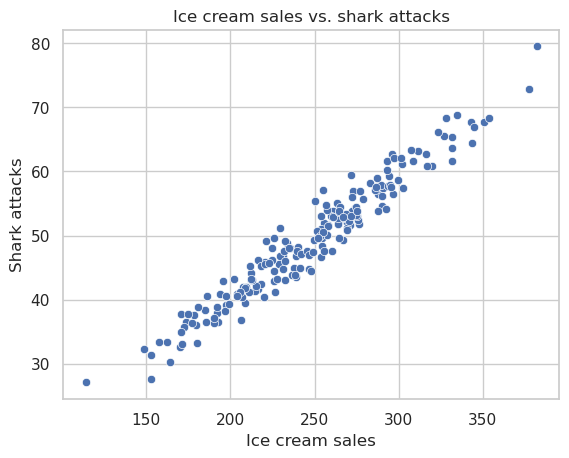

Correlation matrix:
               IceCreamSales  SharkAttacks
IceCreamSales           1.00          0.97
SharkAttacks            0.97          1.00


In [3]:
sns.scatterplot(x='IceCreamSales', y='SharkAttacks', data=df)
plt.title('Ice cream sales vs. shark attacks')
plt.xlabel('Ice cream sales')
plt.ylabel('Shark attacks')
plt.show()

print('Correlation matrix:')
print(df[['IceCreamSales', 'SharkAttacks']].corr().round(2))

If we trusted this plot at face value we would conclude that *selling more ice cream causes more shark attacks*. That is obviously absurd — but the correlation is real, and statistical tests will happily flag it as significant. The correlation is just not coming from a causal link between the two variables.

Now let's add the temperature into a regression and ask: once we account for temperature, does ice cream still predict shark attacks?

In [4]:
def ols_with_se(X, y):
    """Ordinary least squares returning (coefficients, standard errors).

    X must include an intercept column. Standard errors come from
    SE(beta_i) = sqrt(sigma^2 * [(X^T X)^{-1}]_{ii}), with
    sigma^2 = residual sum of squares / (n - p).
    """
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    n, p = X.shape
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ beta
    sigma2 = (resid @ resid) / (n - p)
    cov_beta = sigma2 * np.linalg.inv(X.T @ X)
    se = np.sqrt(np.diag(cov_beta))
    return beta, se

# Design matrices (first column = intercept)
ones = np.ones(len(df))
X_naive = np.column_stack([ones, df['IceCreamSales']])
X_adj   = np.column_stack([ones, df['IceCreamSales'], df['Temperature']])
y       = df['SharkAttacks'].values

b_n, se_n = ols_with_se(X_naive, y)
b_a, se_a = ols_with_se(X_adj,   y)

print('Naive model (SharkAttacks ~ IceCreamSales):')
print(f'  intercept:     {b_n[0]:+7.3f} ± {se_n[0]:.3f}')
print(f'  IceCreamSales: {b_n[1]:+7.3f} ± {se_n[1]:.3f}')
print()
print('Adjusted model (SharkAttacks ~ IceCreamSales + Temperature):')
print(f'  intercept:     {b_a[0]:+7.3f} ± {se_a[0]:.3f}')
print(f'  IceCreamSales: {b_a[1]:+7.3f} ± {se_a[1]:.3f}')
print(f'  Temperature:   {b_a[2]:+7.3f} ± {se_a[2]:.3f}')

Naive model (SharkAttacks ~ IceCreamSales):
  intercept:      +2.186 ± 0.836
  IceCreamSales:  +0.190 ± 0.003

Adjusted model (SharkAttacks ~ IceCreamSales + Temperature):
  intercept:      +1.233 ± 0.763
  IceCreamSales:  -0.008 ± 0.029
  Temperature:    +2.024 ± 0.290


In the naive model the slope on `IceCreamSales` is several standard errors away from zero — a statistically clear, but causally meaningless, association. In the adjusted model, the slope on `IceCreamSales` is comparable in size to its own standard error (consistent with zero), while `Temperature` carries a large, well-determined coefficient. We *conditioned on* (or *controlled for*, or *adjusted for* — all the same thing) temperature, and the apparent effect of ice cream on shark attacks evaporated.

This is the key idea: an observational correlation between $X$ and $Y$ can come from any combination of

- $X$ causes $Y$,
- $Y$ causes $X$,
- a third variable $Z$ causes both.

Correlation alone cannot tell these apart. We need extra structure — some assumption or knowledge about the data-generating process. That structure is most naturally drawn as a graph.

# 3. DAGs: a language for causal structure

A **directed acyclic graph (DAG)** is a picture with:

- **Nodes** = variables.
- **Arrows** = direct causal effects (the source causes the target).
- **Acyclic** = no variable causes itself, even indirectly (no feedback loops, at least not in the version we use today).

The ice cream / shark attacks story is one such graph:

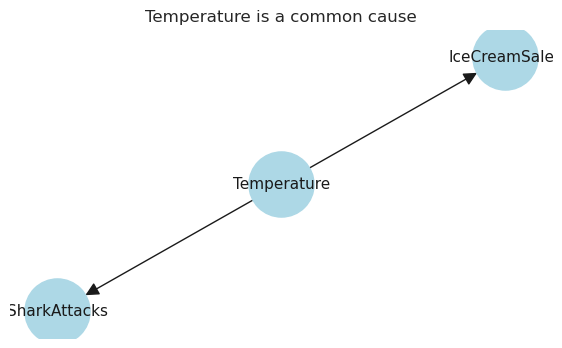

In [5]:
import networkx as nx

def draw_dag(edges, title='Causal DAG', pos=None):
    G = nx.DiGraph()
    G.add_edges_from(edges)
    if pos is None:
        pos = nx.spring_layout(G, seed=42)
    fig, ax = plt.subplots(figsize=(7, 4))
    nx.draw_networkx(G, pos, ax=ax, arrows=True, with_labels=True,
                     node_size=2200, node_color='lightblue', font_size=11,
                     arrowsize=20)
    ax.set_title(title)
    ax.axis('off')
    plt.show()

draw_dag(
    [('Temperature', 'IceCreamSales'), ('Temperature', 'SharkAttacks')],
    title='Temperature is a common cause',
)

Every DAG, no matter how big, is built from three basic local structures. Learning to recognise them is most of the work.

## 3.1 Fork (a confounder): $A \leftarrow C \rightarrow B$

$C$ is a **common cause** of $A$ and $B$. $A$ and $B$ are correlated, but neither causes the other. This is exactly the temperature / ice cream / sharks story.

- **Implication:** without doing anything, $A$ and $B$ look correlated.
- **Fix:** condition on $C$ to remove the spurious association.

## 3.2 Chain (a mediator): $A \rightarrow B \rightarrow C$

$B$ is a **mediator**: it carries the causal influence from $A$ to $C$. Classic example: $\text{Smoking} \rightarrow \text{Tar in lungs} \rightarrow \text{Lung cancer}$.

- **Implication:** $A$ and $C$ are correlated, and there really is a causal link.
- **Warning:** if you condition on $B$, you *block* part of the effect of $A$ on $C$. If your question is "what is the total effect of smoking on cancer?", you should **not** adjust for tar.

## 3.3 Collider (a common effect): $A \rightarrow B \leftarrow C$

$B$ is a **common effect** of $A$ and $C$. This is the structure that surprises people the most.

- **Implication:** with no conditioning, $A$ and $C$ are *independent*.
- **Warning:** if you condition on $B$, you create a spurious correlation between $A$ and $C$ where there was none. This is called **collider bias** or **selection bias**, and it is everywhere in real data.

The collider rule is counter-intuitive, so let's see it numerically.

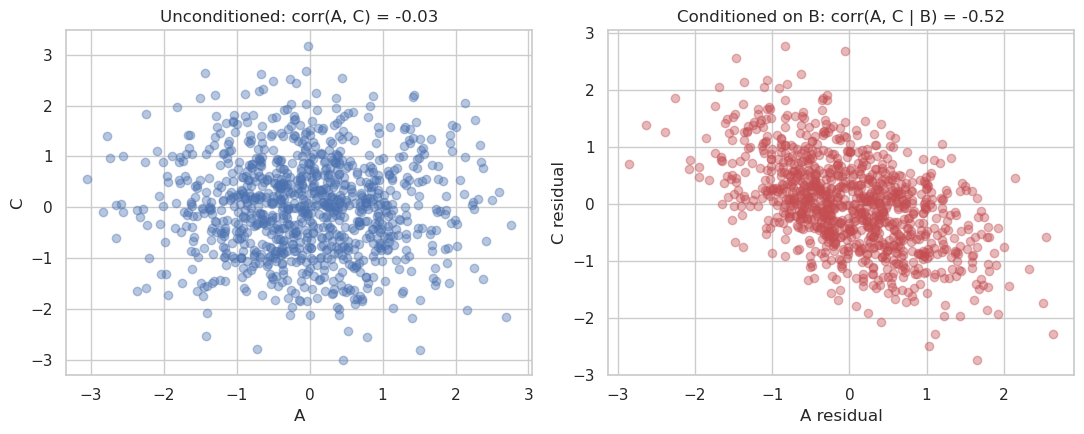

In [6]:
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression

np.random.seed(0)
n = 1000

# Two independent causes, one common effect.
A = np.random.normal(0, 1, n)
C = np.random.normal(0, 1, n)
B = A + C + np.random.normal(0, 1, n)   # B is the collider

def residualize(x, Z):
    """Return the part of x not explained by Z (linearly)."""
    model = LinearRegression().fit(Z, x)
    return x - model.predict(Z)

A_given_B = residualize(A.reshape(-1, 1), B.reshape(-1, 1)).ravel()
C_given_B = residualize(C.reshape(-1, 1), B.reshape(-1, 1)).ravel()

fig, ax = plt.subplots(ncols=2, figsize=(11, 4.5))
ax[0].scatter(A, C, alpha=0.4)
ax[0].set_title(f'Unconditioned: corr(A, C) = {pearsonr(A, C)[0]:+.2f}')
ax[0].set_xlabel('A'); ax[0].set_ylabel('C')

ax[1].scatter(A_given_B, C_given_B, alpha=0.4, color='C3')
ax[1].set_title(f'Conditioned on B: corr(A, C | B) = {pearsonr(A_given_B, C_given_B)[0]:+.2f}')
ax[1].set_xlabel('A residual')
ax[1].set_ylabel('C residual')
plt.tight_layout(); plt.show()

On the left, $A$ and $C$ are independent — we built them that way. On the right, after we condition on the collider $B$, a clear *negative* correlation appears. We invented information by conditioning. The intuitive reason: if $B = A + C$ and we know $B$ is high, then a low value of $A$ implies a high value of $C$, and vice versa. Conditioning on the common effect ties the causes together.

Real-world flavours of collider bias:

- *Sampling on the outcome:* studying only hospitalised patients can make two independent risk factors look anti-correlated, because each is enough to land you in hospital.
- *Selection effects in surveys:* the people who answer the survey are the collider.
- *Berkeley revisited:* admissions outcome is partly a collider between applicant attributes and department choice.

### Summary table (memorise this)

| Structure | Form | What it does on its own | Should you condition on the middle? |
|---|---|---|---|
| Fork (confounder) | $A \leftarrow C \rightarrow B$ | Creates a spurious correlation between $A$ and $B$ | **Yes** — removes spurious correlation |
| Chain (mediator) | $A \rightarrow B \rightarrow C$ | $A$ and $C$ are correlated through $B$ | **No** if you want the total effect of $A$ on $C$ |
| Collider | $A \rightarrow B \leftarrow C$ | $A$ and $C$ are independent | **No** — conditioning *creates* a spurious correlation |

# 4. What to condition on: the practical rule

When you sit down with a dataset and want to estimate the causal effect of a *treatment* $T$ on an *outcome* $Y$, the question is always: **which other variables should I include in my model?** The DAG gives you the answer.

**Rule of thumb:**

1. Draw the DAG that you believe describes the data-generating process. Be explicit about which variables you think cause which others.
2. For each other variable in your dataset, ask: is it a *confounder*, a *mediator*, or a *collider* of $T$ and $Y$?
3. **Adjust for confounders.** **Do not adjust** for mediators (unless you specifically want a direct effect) or for colliders.

Note what this rule overturns: the instinct to "throw everything into the regression" is wrong. Adding more variables can make things worse, not better, if those variables are mediators or colliders.

## Back to Berkeley

In the Berkeley case the DAG looks roughly like

$$\text{Gender} \;\longrightarrow\; \text{Department applied to} \;\longrightarrow\; \text{Admission}$$

Department is a *mediator* of gender's effect on admission. If we want the "direct effect of gender at the admission stage", we condition on department — and that effect turns out to be small or reversed. If we want the "total effect of gender on the chance of being admitted at Berkeley", we should *not* condition on department — and that effect is the aggregate gap.

Different questions, different adjustments, same data. The choice is not statistical, it is causal.

# 5. Estimating causal effects: backdoor adjustment with DoWhy

We now make the rule precise and use a tool that does the bookkeeping for us.

## The backdoor criterion

Given a DAG with treatment $T$ and outcome $Y$, a set of variables $S$ satisfies the **backdoor criterion** if:

1. No variable in $S$ is a descendant of $T$ (so we don't accidentally condition on a mediator or collider downstream of the treatment).
2. $S$ blocks every path from $T$ to $Y$ that starts with an arrow pointing *into* $T$ — these are the "backdoor paths" through which confounding sneaks in.

If such an $S$ exists, conditioning on it gives an unbiased estimate of the causal effect of $T$ on $Y$.

In the ice-cream / sharks example, the only backdoor path from `IceCreamSales` to `SharkAttacks` is `IceCreamSales ← Temperature → SharkAttacks`. Conditioning on `Temperature` blocks it. That is exactly what the regression in section 2 did.

## A simulated example

We build data where we *know* the causal effect, then estimate it with the `DoWhy` library.

In [7]:
from dowhy import CausalModel

np.random.seed(42)
n = 1000

# B is a confounder of T and Y.
# True causal effect of T on Y is 2.
B = np.random.normal(size=n)
T = 0.5 * B + np.random.normal(size=n)
Y = 2.0 * T + 1.5 * B**2 + np.random.normal(size=n)

data = pd.DataFrame({'B': B, 'T': T, 'Y': Y})
data.head()

,B,T,Y
0,0.496714,1.647713,2.990334
1,-0.138264,0.855502,1.595160
2,0.647689,0.383475,0.603780
3,1.523030,0.114578,3.400625
4,-0.234153,0.581147,-0.649080


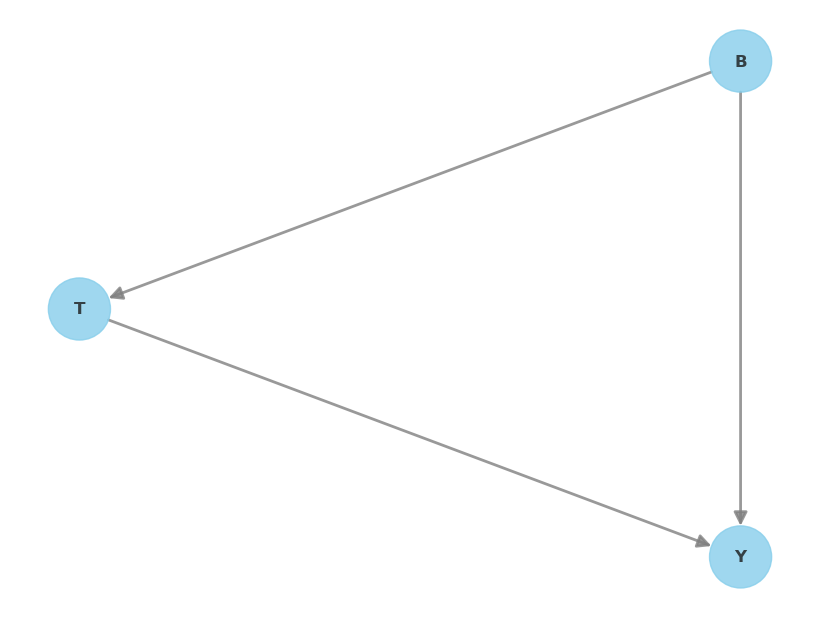

In [8]:
model = CausalModel(
    data=data,
    treatment='T',
    outcome='Y',
    common_causes=['B'],
)
model.view_model(layout='dot')

In [9]:
identified = model.identify_effect()
print(identified)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
 d          
────(E[Y|B])
d[T]        
Estimand assumption 1, Unconfoundedness: If U→{T} and U→Y then P(Y|T,B,U) = P(Y|T,B)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
 d          
────(E[Y|B])
d[T]        
Estimand assumption 1, Unconfoundedness: If U→{T} and U→Y then P(Y|T,B,U) = P(Y|T,B)



In [10]:
estimate = model.estimate_effect(identified, method_name='backdoor.linear_regression')
print(f'True effect:      2.00')
print(f'Estimated effect: {estimate.value:.2f}')

True effect:      2.00
Estimated effect: 2.05


DoWhy walks through three explicit steps:

1. **Model.** You declare your causal DAG (here: $B$ is a common cause of $T$ and $Y$).
2. **Identify.** It asks: given this DAG, is the causal effect of $T$ on $Y$ identifiable from the observed variables? It finds the backdoor estimand $\frac{d}{dT}\,E[Y \mid B]$.
3. **Estimate.** It plugs the data into an estimator (here, linear regression with $B$ as a control) and reports a number.

The estimated effect is very close to the true value of 2 — even though the confounder enters $Y$ *nonlinearly* (through $B^2$), linear adjustment recovers the treatment coefficient well because $T$ depends on $B$ linearly. The separation of *identification* (a graphical question) from *estimation* (a modelling question) is what makes this framework powerful: you can swap the estimator without rethinking the DAG.

# 6. Beyond: causal discovery

Throughout this class we *assumed* the DAG. That is the standard setting of **causal inference**: data + DAG → effects.

The reverse problem — learning the DAG itself from data — is called **causal discovery**, and it is much harder. In general the DAG is not identifiable from observational data alone (think: $X \rightarrow Y$ and $Y \rightarrow X$ can produce the same correlations), so causal discovery algorithms rely on extra assumptions: faithfulness, noise distributions, interventions, time order, etc.

A practical starting point in Python is the `pywhy` ecosystem. See for example the falsification tools in DoWhy's `gcm` module:

- https://www.pywhy.org/dowhy/v0.10/example_notebooks/gcm_falsify_dag.html

---

### Recap

- Correlation can be created by a third variable. Always ask: where could a confounder hide?
- Draw the DAG before the regression.
- Adjust for confounders. Leave mediators and colliders alone (in general).
- Given a DAG, backdoor adjustment turns observational data into a causal estimate.